<a href="https://colab.research.google.com/github/jpccmacedo-cmyk/CEP---MVP/blob/main/MVP_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Controle Estatístico de Processo (CEP)
**Aluno:** João Pedro Cavalcante Castro Macedo  
**Matrícula:** 202029219  
**Disciplina:** CEP - Engenharia de Produção - UnB

**Professor:** Dr. Andre Luiz Marques Serrano

**Tema:** CEP na Agroindústria: Classificação Preditiva e Controle de Qualidade na Produção de Cafés Especiais.
**Dataset:** Coffee Quality Database (CQI) - Kaggle.

---

## 1. Definição do Problema

* **Objetivo:** Desenvolver um modelo preditivo de classificação capaz de antecipar se um lote de café atingirá o grau de "Café Especial" (nota global >= 80) com base em avaliações sensoriais intermediárias e atributos físicos do grão (umidade e número de defeitos).
* **Descrição do problema:** Na agroindústria do café, o valor de mercado flutua drasticamente. Lotes com pontuação global acima de 80 pontos na escala CQI são exportados como cafés especiais (alto valor). A aplicação do CEP preditivo permite que a cooperativa identifique lotes promissores precocemente e atue na correção de falhas de armazenagem (como excesso de umidade que gera defeitos).
* **Hipóteses:** Atributos como Acidez (Acidity) e Sabor (Flavor) terão alta correlação com a aprovação do lote, enquanto a presença de defeitos primários (Category One Defects) e alta umidade atuarão como ofensores da qualidade.
* **Dataset:** A base contém dados de mais de 1300 lotes de café Arábica, avaliados pelo Coffee Quality Institute. Utilizaremos atributos contínuos para prever uma classe binária.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Fixar seeds para reprodutibilidade (Boas Práticas)
SEED = 42
np.random.seed(SEED)

# Carga dos dados (Acessando o repositório raw no GitHub com a base limpa do Kaggle)
url = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"
df = pd.read_csv(url)

# Selecionando apenas as colunas relevantes para o controle de processo e qualidade
features = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
            'Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'Total.Cup.Points']

df = df[features]

# Exibir as primeiras linhas
display(df.head())
df.info()

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Moisture,Category.One.Defects,Category.Two.Defects,Total.Cup.Points
0,8.67,8.83,8.67,8.75,8.50,8.42,0.12,0,0,90.58
1,8.75,8.67,8.50,8.58,8.42,8.42,0.12,0,1,89.92
2,8.42,8.50,8.42,8.42,8.33,8.42,0.00,0,0,89.75
3,8.17,8.58,8.42,8.42,8.50,8.25,0.11,0,2,89.00
4,8.25,8.50,8.25,8.50,8.42,8.33,0.12,0,2,88.83


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Aroma                 1311 non-null   float64
 1   Flavor                1311 non-null   float64
 2   Aftertaste            1311 non-null   float64
 3   Acidity               1311 non-null   float64
 4   Body                  1311 non-null   float64
 5   Balance               1311 non-null   float64
 6   Moisture              1311 non-null   float64
 7   Category.One.Defects  1311 non-null   int64  
 8   Category.Two.Defects  1311 non-null   int64  
 9   Total.Cup.Points      1311 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 102.6 KB


## 2. Preparação de Dados

* **Limpeza:** A base possui alguns valores nulos (NaNs) e outliers extremos em umidade. Faremos a remoção das linhas com dados faltantes para garantir a integridade do modelo.
* **Engenharia da Variável Alvo:** A coluna original `Total.Cup.Points` é contínua. Nós a transformaremos em uma variável binária `Specialty` para facilitar a decisão operacional: 1 (Aprovado como Especial, $\ge 80$) e 0 (Rebaixado para Comercial, $< 80$).
* **Divisão e Padronização:** Separaremos 80% dos lotes para treino e 20% para teste, usando `stratify` para balancear a proporção de cafés especiais e comerciais. Aplicaremos o `StandardScaler` apenas no conjunto de treino para evitar vazamento de dados.

In [ ]:
# 1. Tratamento de Dados e Limpeza
df = df.dropna()

# Binarização da variável alvo (Regra de negócio do mercado de café)
df['Specialty_bin'] = df['Total.Cup.Points'].apply(lambda x: 1 if x >= 80 else 0)

# Verificando a distribuição das classes
print("Distribuição da Qualidade no Dataset:")
print(df['Specialty_bin'].value_counts())

# Separação de features (X) e target (y)
X = df.drop(['Total.Cup.Points', 'Specialty_bin'], axis=1)
y = df['Specialty_bin']

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Padronização (Ajuste exclusivo no treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nLotes para Treino: {X_train.shape[0]}")
print(f"Lotes para Teste: {X_test.shape[0]}")

Distribuição da Qualidade no Dataset:
Specialty_bin
1    1130
0     181
Name: count, dtype: int64

Lotes para Treino: 1048
Lotes para Teste: 263


## 3. Modelagem e Treinamento

* **Seleção de Algoritmos:** Utilizaremos o algoritmo *Random Forest Classifier*. Em agroindústria, as relações físico-químicas não são estritamente lineares (ex: umidade a 11% é boa, mas a 14% destrói o lote). O comitê de árvores lida perfeitamente com esses limiares.
* **Otimização de Hiperparâmetros:** Exploraremos o `GridSearchCV` para encontrar a melhor profundidade de árvore e o número ideal de estimadores, aplicando validação cruzada para garantir robustez.

In [ ]:
# Ensemble com Otimização (Random Forest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=SEED)

print("Treinando e otimizando o modelo...")
t0_rf = time.time()
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_

print(f"Tempo de Treinamento: {time.time() - t0_rf:.2f}s")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Acurácia no Treino: {best_rf.score(X_train_scaled, y_train):.4f}")

Treinando e otimizando o modelo...
Tempo de Treinamento: 34.79s
Melhores parâmetros encontrados: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Acurácia no Treino: 0.9676


## 4. Avaliação de Resultados e Importância das Variáveis

* **Métricas:** Analisaremos o Relatório de Classificação nos dados de teste. Para a cooperativa, classificar erroneamente um lote ruim como "Especial" (Falso Positivo) causa devoluções e multas no exterior. O modelo precisa ser preciso.
* **Plano de Ação:** O gráfico de *Feature Importance* indicará ao gestor do terreiro e da secagem quais atributos sensoriais ou defeitos físicos merecem maior alocação de recursos preventivos.

 DESEMPENHO: RANDOM FOREST OTIMIZADO 
                 precision    recall  f1-score   support

Comercial (<80)       0.93      0.72      0.81        36
Especial (>=80)       0.96      0.99      0.97       227

       accuracy                           0.95       263
      macro avg       0.94      0.86      0.89       263
   weighted avg       0.95      0.95      0.95       263



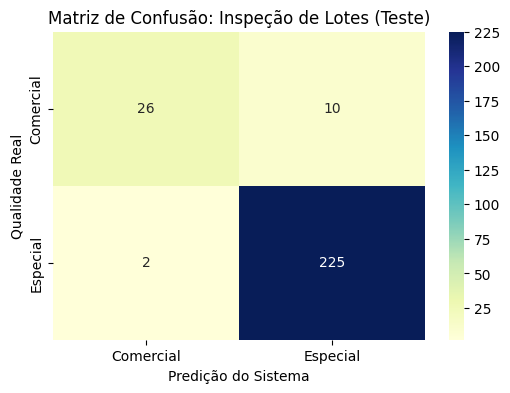

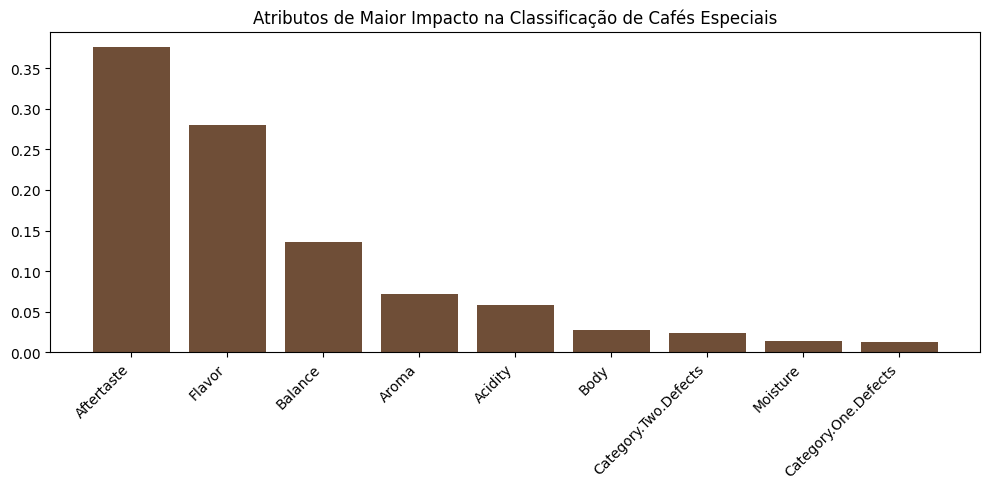

In [ ]:
# Predições na base de teste
y_pred_rf = best_rf.predict(X_test_scaled)

print("="*55)
print(" DESEMPENHO: RANDOM FOREST OTIMIZADO ")
print("="*55)
print(classification_report(y_test, y_pred_rf, target_names=['Comercial (<80)', 'Especial (>=80)']))

# Matriz de Confusão
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Comercial', 'Especial'], yticklabels=['Comercial', 'Especial'])
plt.title('Matriz de Confusão: Inspeção de Lotes (Teste)')
plt.ylabel('Qualidade Real')
plt.xlabel('Predição do Sistema')
plt.show()

# Importância das Variáveis para o Processo
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Atributos de Maior Impacto na Classificação de Cafés Especiais")
plt.bar(range(X.shape[1]), importances[indices], color='#6F4E37') # Cor de café
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. CEP Clássico: Controle de Variáveis no Beneficiamento (Cartas $\bar{X}$ e $R$)

* **Conceito:** Segundo Montgomery, antes de analisarmos a capacidade preditiva do processo, precisamos garantir que o processo base está em estado de controle estatístico. Utilizaremos as cartas $\bar{X}$ (Média) e $R$ (Amplitude).
* **Parâmetro Crítico (CTQ):** Analisaremos a **Umidade (Moisture)** dos lotes. A estabilidade na secagem é o alicerce para a qualidade sensorial do café especial.
* **Subgrupos:** Como a base de dados avalia lotes individuais, agruparemos os dados cronologicamente em subgrupos racionais de tamanho $n=5$ para estimar a variabilidade intrínseca do processo de secagem.
* **Cálculo dos Limites:** Utilizaremos as constantes estatísticas tabeladas para $n=5$ ($A_2 = 0.577$, $D_3 = 0.0$, $D_4 = 2.114$).
    * Limites de $\bar{X}$: $LSC = \overline{\overline{X}} + A_2\bar{R}$ e $LIC = \overline{\overline{X}} - A_2\bar{R}$
    * Limites de $R$: $LSC = D_4\bar{R}$ e $LIC = D_3\bar{R}$

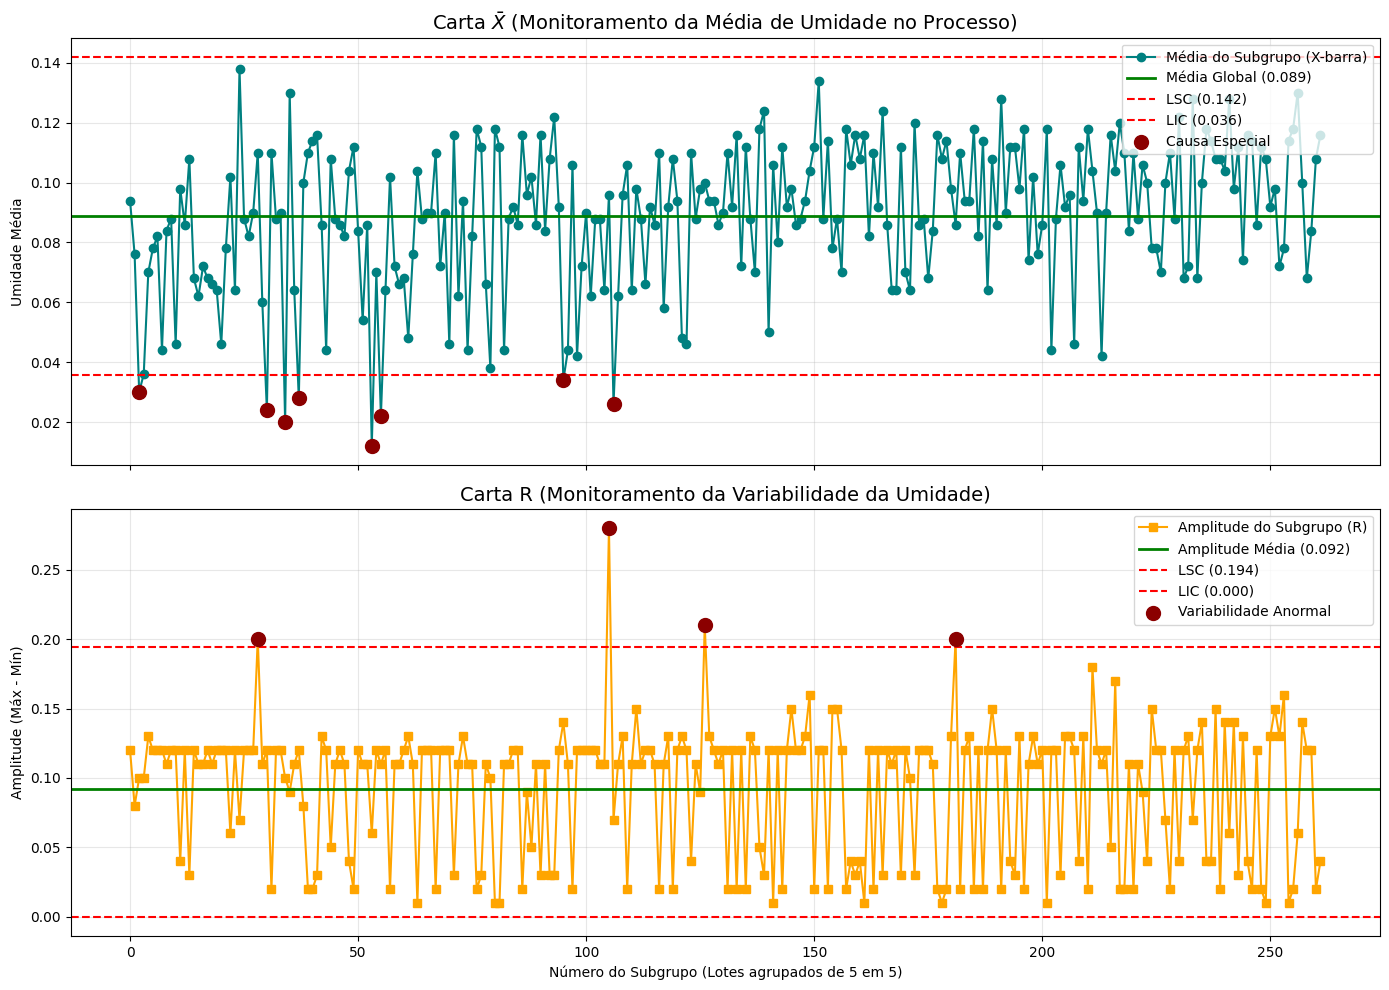

 DIAGNÓSTICO DE ESTABILIDADE DO PROCESSO (CEP CLÁSSICO) 
Total de subgrupos analisados: 262
Pontos fora de controle na Média (X-barra): 8
Pontos fora de controle na Variabilidade (R): 4
Conclusão Técnica: O gráfico indica se o processo de secagem possui causas especiais de variação antes de alimentarmos o modelo de Machine Learning.


In [ ]:
# Célula 1.5: Aplicação das Cartas X-barra e R (Baseado em Montgomery)

# 1. Preparação dos dados para subgrupos de tamanho n=5
n = 5
# Filtramos apenas os dados válidos de umidade
dados_umidade = df['Moisture'].dropna().values
# Garantimos que o total de amostras seja um múltiplo exato de n
dados_umidade = dados_umidade[:(len(dados_umidade) // n) * n]
# Reorganizamos o vetor em uma matriz onde cada linha é um subgrupo de 5 lotes
subgrupos = dados_umidade.reshape(-1, n)

# 2. Cálculos das Médias e Amplitudes por subgrupo
x_barra = np.mean(subgrupos, axis=1) # Média de cada subgrupo
r = np.ptp(subgrupos, axis=1)        # Amplitude de cada subgrupo (Max - Min)

# Cálculos das Linhas Centrais (Médias Globais)
x_duas_barras = np.mean(x_barra)
r_barra = np.mean(r)

# 3. Constantes de Controle para n=5
A2 = 0.577
D3 = 0.0
D4 = 2.114

# 4. Cálculo dos Limites de Controle
LSC_X = x_duas_barras + (A2 * r_barra)
LIC_X = max(0, x_duas_barras - (A2 * r_barra)) # Umidade não pode ser negativa

LSC_R = D4 * r_barra
LIC_R = max(0, D3 * r_barra)

# 5. Plotagem das Cartas de Controle Clássicas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Gráfico X-barra (Médias) ---
ax1.plot(x_barra, marker='o', color='teal', linestyle='-', linewidth=1.5, label='Média do Subgrupo (X-barra)')
ax1.axhline(x_duas_barras, color='green', linestyle='-', linewidth=2, label=f'Média Global ({x_duas_barras:.3f})')
ax1.axhline(LSC_X, color='red', linestyle='--', linewidth=1.5, label=f'LSC ({LSC_X:.3f})')
ax1.axhline(LIC_X, color='red', linestyle='--', linewidth=1.5, label=f'LIC ({LIC_X:.3f})')

# Identificando pontos fora de controle na carta X-barra
out_of_control_x = np.where((x_barra > LSC_X) | (x_barra < LIC_X))[0]
ax1.scatter(out_of_control_x, x_barra[out_of_control_x], color='darkred', s=100, zorder=5, label='Causa Especial')

ax1.set_title('Carta $\\bar{X}$ (Monitoramento da Média de Umidade no Processo)', fontsize=14)
ax1.set_ylabel('Umidade Média')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Gráfico R (Amplitudes) ---
ax2.plot(r, marker='s', color='orange', linestyle='-', linewidth=1.5, label='Amplitude do Subgrupo (R)')
ax2.axhline(r_barra, color='green', linestyle='-', linewidth=2, label=f'Amplitude Média ({r_barra:.3f})')
ax2.axhline(LSC_R, color='red', linestyle='--', linewidth=1.5, label=f'LSC ({LSC_R:.3f})')
ax2.axhline(LIC_R, color='red', linestyle='--', linewidth=1.5, label=f'LIC ({LIC_R:.3f})')

# Identificando pontos fora de controle na carta R
out_of_control_r = np.where((r > LSC_R) | (r < LIC_R))[0]
ax2.scatter(out_of_control_r, r[out_of_control_r], color='darkred', s=100, zorder=5, label='Variabilidade Anormal')

ax2.set_title('Carta R (Monitoramento da Variabilidade da Umidade)', fontsize=14)
ax2.set_xlabel('Número do Subgrupo (Lotes agrupados de 5 em 5)')
ax2.set_ylabel('Amplitude (Máx - Mín)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumo do CEP Clássico
print("="*60)
print(" DIAGNÓSTICO DE ESTABILIDADE DO PROCESSO (CEP CLÁSSICO) ")
print("="*60)
print(f"Total de subgrupos analisados: {len(x_barra)}")
print(f"Pontos fora de controle na Média (X-barra): {len(out_of_control_x)}")
print(f"Pontos fora de controle na Variabilidade (R): {len(out_of_control_r)}")
print("Conclusão Técnica: O gráfico indica se o processo de secagem possui causas especiais de variação antes de alimentarmos o modelo de Machine Learning.")